### Install libraries

In [1]:
!pip install openpyxl

    scikit-learn (>=1.0.*) ; extra == 'pipelines'
                  ~~~~~~^


### Load Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import yfinance as yf
import openpyxl

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

### Configuration & Data Loading

In [3]:
RAW_DATA_PATH = "data/raw_data.csv"
CPI_PATH = "data/cpi.xlsx"
KIBOR_PATH = "data/kibor_rate.csv"

INITIAL_CAPITAL = 100000
BUY_THRESHOLD = 0.05
SELL_THRESHOLD = -0.05

RANDOM_STATE = 42

# Annual GDP growth values provided by the user
GDP_BY_YEAR = {
    2021: 6.513885759,
    2022: 4.778106869,
    2023: -0.414936,
    2024: 3.048982873,
    2025: 2.70
}

# Annual inflation values provided by the user
INFLATION_BY_YEAR = {
    2021: 9.496211,
    2022: 19.87386,
    2023: 30.76813,
    2024: 12.63253,
    2025: np.nan
}

### Helper Functions & Feature Engineering

In [4]:
def clean_numeric(val):
    """
    Converts strings like '45,000', '2.3M', '5.4%', etc. into numeric values.
    """
    if pd.isna(val):
        return np.nan

    if isinstance(val, str):
        val = val.replace(",", "").replace("%", "").strip()

        if val == "":
            return np.nan

        multiplier_map = {"K": 1e3, "M": 1e6, "B": 1e9}
        for suffix, multiplier in multiplier_map.items():
            if val.endswith(suffix):
                try:
                    return float(val[:-1]) * multiplier
                except ValueError:
                    return np.nan

        try:
            return float(val)
        except ValueError:
            return np.nan

    return val

In [5]:
def fetch_yfinance_close_series(ticker, start_date, end_date, output_col_name):
    """
    Pulls daily close prices from Yahoo Finance and returns a Date/Close dataframe.
    """
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date + pd.Timedelta(days=5),
        auto_adjust=False,
        progress=False
    )

    if data.empty:
        raise RuntimeError(
            f"Yahoo Finance returned no data for {ticker}. "
            f"Check internet access and ticker validity."
        )

    if isinstance(data.columns, pd.MultiIndex):
        close_series = data["Close"].iloc[:, 0]
    else:
        close_series = data["Close"]

    out = close_series.reset_index()
    out.columns = ["Date", output_col_name]
    out["Date"] = pd.to_datetime(out["Date"])
    return out


In [6]:
def prepare_cpi_monthly(cpi_path):
    """
    Converts the uploaded CPI workbook from wide format into a monthly long format.
    Drops annual and quarterly values and keeps monthly values only.
    Returns a monthly merge key plus the CPI value.
    """
    cpi_wide = pd.read_excel(cpi_path)

    row = cpi_wide.iloc[0].to_dict()
    monthly_rows = []

    for key, value in row.items():
        if isinstance(key, str) and "-M" in key:
            year_str, month_str = key.split("-M")
            monthly_rows.append({
                "cpi_month_key": pd.Period(f"{year_str}-{month_str}", freq="M"),
                "cpi": pd.to_numeric(value, errors="coerce")
            })

    cpi_monthly = (
        pd.DataFrame(monthly_rows)
        .sort_values("cpi_month_key")
        .reset_index(drop=True)
    )

    return cpi_monthly


In [7]:
def prepare_kibor(kibor_path):
    """
    Loads daily KIBOR data and standardizes the column names.
    """
    kibor = pd.read_csv(kibor_path)
    kibor["Date"] = pd.to_datetime(kibor["Observation Date"], format="%d-%b-%y", errors="coerce")
    kibor["kibor_rate"] = pd.to_numeric(kibor["Observation Value"], errors="coerce")
    kibor = kibor[["Date", "kibor_rate"]].dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    return kibor

In [8]:
def compute_rsi(series, period=14):
    """
    Computes Relative Strength Index.
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(com=period - 1, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, adjust=False, min_periods=period).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [9]:
def days_since_rolling_high(close_series, window):
    """
    Number of trading days since the most recent rolling-window high.
    """
    return close_series.rolling(window, min_periods=window).apply(
        lambda x: (len(x) - 1) - np.argmax(x),
        raw=True
    )

In [10]:
def add_drawdown_features(df, window):
    """
    Adds rolling drawdown features for a given lookback window.
    """
    # Rolling peak close over the last {window} trading days ending at t
    df[f"rolling_max_close_{window}"] = df["Close"].rolling(window, min_periods=window).max()

    # Current drawdown from the rolling peak; values are <= 0
    df[f"drawdown_{window}"] = df["Close"] / df[f"rolling_max_close_{window}"] - 1

    # Worst drawdown seen inside the same rolling window
    df[f"max_drawdown_{window}"] = df[f"drawdown_{window}"].rolling(window, min_periods=window).min()

    # Trading days since the most recent high in the rolling window
    df[f"days_since_high_{window}"] = days_since_rolling_high(df["Close"], window)

    return df

In [11]:
def add_technical_features(df):
    """
    Adds technical, volatility, regime, liquidity, and drawdown features.
    Uses only information available as of date t.
    """
    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]
    prev_close = df["prev_close"]

    # Simple moving averages over short, medium, and long windows
    for w in [10, 20, 50, 200]:
        df[f"SMA_{w}"] = close.rolling(w, min_periods=w).mean()

    # Exponential moving averages that weight recent prices more heavily
    for w in [10, 20, 50]:
        df[f"EMA_{w}"] = close.ewm(span=w, adjust=False, min_periods=w).mean()

    # Binary bull regime flag based on 50-day vs 200-day simple moving average
    df["Golden_Cross"] = (df["SMA_50"] > df["SMA_200"]).astype(float)

    # Binary short-term momentum crossover flag based on 10-day vs 20-day EMA
    df["EMA_crossover"] = (df["EMA_10"] > df["EMA_20"]).astype(float)

    # 14-day RSI momentum oscillator
    df["RSI_14"] = compute_rsi(close, period=14)

    # Overbought flag when RSI is above 70
    df["RSI_OB"] = (df["RSI_14"] > 70).astype(float)

    # Oversold flag when RSI is below 30
    df["RSI_OS"] = (df["RSI_14"] < 30).astype(float)

    # MACD line using 12-day EMA minus 26-day EMA
    df["MACD_Line"] = close.ewm(span=12, adjust=False, min_periods=12).mean() - \
                      close.ewm(span=26, adjust=False, min_periods=26).mean()

    # MACD signal line using 9-day EMA of MACD
    df["MACD_Signal"] = df["MACD_Line"].ewm(span=9, adjust=False, min_periods=9).mean()

    # MACD histogram measuring MACD minus signal
    df["MACD_Hist"] = df["MACD_Line"] - df["MACD_Signal"]

    # 5-day rate of change in percent
    df["ROC_5"] = close.pct_change(5) * 100

    # 20-day Bollinger middle band
    bb_mid = close.rolling(20, min_periods=20).mean()

    # 20-day Bollinger rolling standard deviation
    bb_std = close.rolling(20, min_periods=20).std()

    # Upper Bollinger band
    df["BB_Upper"] = bb_mid + 2 * bb_std

    # Lower Bollinger band
    df["BB_Lower"] = bb_mid - 2 * bb_std

    # Middle Bollinger band
    df["BB_Middle"] = bb_mid

    # Relative Bollinger band width as a volatility measure
    df["BB_Width"] = (df["BB_Upper"] - df["BB_Lower"]) / bb_mid

    # Position of close within Bollinger bands
    df["BB_Pct"] = (close - df["BB_Lower"]) / (df["BB_Upper"] - df["BB_Lower"]).replace(0, np.nan)

    # True Range using current high-low and gaps from previous close
    df["True_Range"] = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)

    # 14-day ATR as smoothed true range
    df["ATR_14"] = df["True_Range"].ewm(span=14, adjust=False, min_periods=14).mean()

    # ATR scaled by price in percent
    df["ATR_Pct"] = df["ATR_14"] / close * 100

    # 20-day historical volatility annualized from log returns
    df["HV_20"] = np.log(close / prev_close).rolling(20, min_periods=20).std() * np.sqrt(252) * 100

    # 20-day average volume
    df["Volume_SMA_20"] = volume.rolling(20, min_periods=20).mean()

    # Today's volume relative to 20-day average volume
    df["Vol_Ratio"] = volume / df["Volume_SMA_20"]

    # 20-day rolling median volume for more robust volume regime detection
    df["Volume_Median_20"] = volume.rolling(20, min_periods=20).median()

    # Volume regime defined as current volume divided by 20-day rolling median volume
    df["Volume_Regime"] = volume / df["Volume_Median_20"]

    # Trend regime defined as distance between 20-day and 50-day moving averages scaled by 50-day average
    df["Trend_Regime"] = (df["SMA_20"] - df["SMA_50"]) / df["SMA_50"]

    # Liquidity stress defined as high true range relative to current volume
    df["Liquidity_Stress"] = df["True_Range"] / volume.replace(0, np.nan)

    # 5-day rolling average KIBOR
    df["kibor_rate_ma_5"] = df["kibor_rate"].rolling(5, min_periods=1).mean()

    # 20-day rolling average KIBOR
    df["kibor_rate_ma_20"] = df["kibor_rate"].rolling(20, min_periods=1).mean()

    # 5-day change in KIBOR rate
    df["kibor_rate_change_5"] = df["kibor_rate"] - df["kibor_rate"].shift(5)

    # 20-day change in KIBOR rate
    df["kibor_rate_change_20"] = df["kibor_rate"] - df["kibor_rate"].shift(20)

    # Lagged close prices for autoregressive structure
    for lag in [1, 2, 3, 5, 10]:
        df[f"close_lag_{lag}"] = close.shift(lag)

    # Lagged daily returns for short-term memory in returns
    for lag in [1, 2, 3, 5, 10]:
        df[f"return_lag_{lag}"] = df["daily_return"].shift(lag)

    # Drawdown features over 63 trading days
    df = add_drawdown_features(df, 63)

    # Drawdown features over 252 trading days
    df = add_drawdown_features(df, 252)

    return df

In [12]:
def calculate_vif(dataframe, feature_list):
    """
    Computes VIF for a list of numeric features.
    """
    X = dataframe[feature_list].copy()
    X = X.dropna()

    if X.empty or X.shape[1] < 2:
        return pd.DataFrame(columns=["feature", "VIF"])

    vif_df = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    return vif_df

In [13]:
def iterative_vif_filter(dataframe, feature_list, vif_threshold=10.0):
    """
    Iteratively removes features with VIF above the threshold.
    """
    selected = feature_list.copy()

    while True:
        vif_df = calculate_vif(dataframe, selected)

        if vif_df.empty:
            break

        max_vif = vif_df["VIF"].max()

        if max_vif <= vif_threshold:
            break

        drop_feature = vif_df.loc[vif_df["VIF"].idxmax(), "feature"]
        selected.remove(drop_feature)

    return selected


In [14]:
def chronological_split(df, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    """
    Time-series split preserving chronological order.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [15]:
def regression_metrics(y_true, y_pred):
    """
    Standard regression metrics.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [16]:
def generate_trade_signal(predicted_next_close, current_close, buy_threshold=0.05, sell_threshold=-0.05):
    """
    Converts predicted next-day price into buy/hold/sell signal.
    """
    predicted_return = predicted_next_close / current_close - 1

    if predicted_return > buy_threshold:
        return "BUY"
    elif predicted_return < sell_threshold:
        return "SELL"
    else:
        return "HOLD"

In [17]:
def run_backtest(signal_df, initial_capital=100000):
    """
    Simple long-cash backtest:
    - BUY: deploy all available cash into the index at today's close
    - SELL: liquidate all holdings at today's close
    - HOLD: keep current position
    """
    cash = initial_capital
    units = 0.0
    portfolio_values = []
    positions = []

    for _, row in signal_df.iterrows():
        price = row["Close"]
        signal = row["trade_signal"]

        if signal == "BUY" and cash > 0:
            units = cash / price
            cash = 0.0

        elif signal == "SELL" and units > 0:
            cash = units * price
            units = 0.0

        portfolio_value = cash + units * price
        portfolio_values.append(portfolio_value)
        positions.append(units)

    signal_df = signal_df.copy()
    signal_df["units_held"] = positions
    signal_df["portfolio_value"] = portfolio_values

    benchmark_start = signal_df["Close"].iloc[0]
    signal_df["benchmark_index_value"] = initial_capital * (signal_df["Close"] / benchmark_start)

    return signal_df

### Load data

In [18]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df["Date"] = pd.to_datetime(raw_df["Date"], errors="coerce")

raw_df = raw_df.sort_values("Date").drop_duplicates(subset=["Date"]).reset_index(drop=True)

numeric_cols = [
    "Price", "Open", "High", "Low", "Vol.", "Change %",
    "Log_Return", "SPY_Log_Return", "EEM_Log_Return",
    "VIX_Level", "VIX_Change", "Days_Since_Last_Trade",
    "Is_Post_Holiday", "Is_IMF_Event", "IMF_3Day_Window"
]

In [19]:
for col in numeric_cols:
    raw_df[col] = raw_df[col].apply(clean_numeric)

# Standardize naming for modeling and feature engineering
base_df = raw_df.copy()

# Close price aligned to expected OHLC convention
base_df["Close"] = base_df["Price"]

# Volume cleaned from the original volume column
base_df["Volume"] = base_df["Vol."]

# Previous trading day close
base_df["prev_close"] = base_df["Close"].shift(1)

# Daily close-to-close return
base_df["daily_return"] = base_df["Close"].pct_change()

# Calendar year for annual macro merges
base_df["year"] = base_df["Date"].dt.year

# Temporary monthly key used only for CPI merge
base_df["cpi_month_key"] = base_df["Date"].dt.to_period("M")

print("Base raw data shape:", base_df.shape)
display(base_df.head())


Base raw data shape: (1227, 22)


,Date,Price,Open,High,Low,Vol.,Change %,Log_Return,SPY_Log_Return,EEM_Log_Return,VIX_Level,VIX_Change,Days_Since_Last_Trade,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,Close,Volume,prev_close,daily_return,year,cpi_month_key
0,2021-03-09,44222.91,45051.06,45129.55,43946.30,NaN,-1.84,-0.018553,-0.004991,-0.027306,25.469999,0.809999,1,0,0,0,44222.91,NaN,NaN,NaN,2021,2021-03
1,2021-03-10,43691.68,44222.91,44424.04,43620.84,NaN,-1.20,-0.012085,0.014176,0.021717,24.030001,-1.439999,1,0,0,0,43691.68,NaN,44222.91,-0.012013,2021,2021-03
2,2021-03-11,42779.76,43691.68,43891.00,42689.42,NaN,-2.09,-0.021093,0.006205,-0.004493,22.559999,-1.470001,1,0,0,0,42779.76,NaN,43691.68,-0.020872,2021,2021-03
3,2021-03-12,43788.08,42779.76,43986.18,42779.76,NaN,2.36,0.023297,0.010088,0.031039,21.910000,-0.650000,1,0,0,0,43788.08,NaN,42779.76,0.023570,2021,2021-03
4,2021-03-15,44766.59,43788.08,44839.19,43788.08,NaN,2.23,0.022100,0.001346,-0.017989,20.690001,-1.219999,3,1,0,0,44766.59,NaN,43788.08,0.022346,2021,2021-03


#### Fetch yFinance data

In [20]:
start_date = base_df["Date"].min()
end_date = base_df["Date"].max()

# SPY daily close
spy_df = fetch_yfinance_close_series("SPY", start_date, end_date, "SPY_Close")

# VEA daily close
vea_df = fetch_yfinance_close_series("VEA", start_date, end_date, "VEA_Close")

# USD/PKR daily close from Yahoo Finance
# Assumption: PKR=X represents PKR per 1 USD
usdpkr_df = fetch_yfinance_close_series("PKR=X", start_date, end_date, "USDPKR_Close")

# Merge daily external market data
base_df = base_df.merge(spy_df, on="Date", how="left")
base_df = base_df.merge(vea_df, on="Date", how="left")
base_df = base_df.merge(usdpkr_df, on="Date", how="left")

# Daily external log-return features
base_df["SPY_Close_Log_Return"] = np.log(base_df["SPY_Close"] / base_df["SPY_Close"].shift(1))
base_df["VEA_Close_Log_Return"] = np.log(base_df["VEA_Close"] / base_df["VEA_Close"].shift(1))
base_df["USDPKR_Log_Return"] = np.log(base_df["USDPKR_Close"] / base_df["USDPKR_Close"].shift(1))


#### Add GDP and Inflation data

In [21]:
# Annual GDP growth mapped by year
base_df["annual_gdp_growth"] = base_df["year"].map(GDP_BY_YEAR)

# Annual inflation mapped by year
base_df["annual_inflation"] = base_df["year"].map(INFLATION_BY_YEAR)

In [22]:
# CPI: KEEP MONTHLY VALUES ONLY

cpi_monthly = prepare_cpi_monthly(CPI_PATH)

base_df = base_df.merge(
    cpi_monthly,
    on="cpi_month_key",
    how="left",
    validate="m:1"
)

# Drop the temporary CPI monthly merge key so the final dataset keeps only one date column
base_df = base_df.drop(columns=["cpi_month_key"])

In [23]:
# KIBOR: DAILY VALUES ONLY FOR RAW DATA DATES

kibor_df = prepare_kibor(KIBOR_PATH)
base_df = base_df.merge(kibor_df, on="Date", how="left")

In [24]:
# Missing value check

missing_check = base_df.isna().sum().sort_values(ascending=False)
print("Missing value check:")
display(missing_check[missing_check > 0])

print("Final merged base dataset shape:", base_df.shape)
display(base_df.head())

Missing value check:


Vol.                    796
Volume                  796
annual_inflation        286
VEA_Close_Log_Return     91
SPY_Close_Log_Return     91
VEA_Close                45
SPY_Close                45
annual_gdp_growth        36
kibor_rate               20
cpi                      14
USDPKR_Log_Return         8
USDPKR_Close              4
daily_return              1
prev_close                1
dtype: int64

Final merged base dataset shape: (1227, 31)


,Date,Price,Open,High,Low,Vol.,Change %,Log_Return,SPY_Log_Return,EEM_Log_Return,VIX_Level,VIX_Change,Days_Since_Last_Trade,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,Close,Volume,prev_close,daily_return,year,SPY_Close,VEA_Close,USDPKR_Close,SPY_Close_Log_Return,VEA_Close_Log_Return,USDPKR_Log_Return,annual_gdp_growth,annual_inflation,cpi,kibor_rate
0,2021-03-09,44222.91,45051.06,45129.55,43946.30,NaN,-1.84,-0.018553,-0.004991,-0.027306,25.469999,0.809999,1,0,0,0,44222.91,NaN,NaN,NaN,2021,387.170013,48.900002,156.750000,NaN,NaN,NaN,6.513886,9.496211,143.61,7.66
1,2021-03-10,43691.68,44222.91,44424.04,43620.84,NaN,-1.20,-0.012085,0.014176,0.021717,24.030001,-1.439999,1,0,0,0,43691.68,NaN,44222.91,-0.012013,2021,389.579987,49.110001,156.649994,0.006205,0.004285,-0.000638,6.513886,9.496211,143.61,7.66
2,2021-03-11,42779.76,43691.68,43891.00,42689.42,NaN,-2.09,-0.021093,0.006205,-0.004493,22.559999,-1.470001,1,0,0,0,42779.76,NaN,43691.68,-0.020872,2021,393.529999,49.470001,156.699997,0.010088,0.007304,0.000319,6.513886,9.496211,143.61,7.87
3,2021-03-12,43788.08,42779.76,43986.18,42779.76,NaN,2.36,0.023297,0.010088,0.031039,21.910000,-0.650000,1,0,0,0,43788.08,NaN,42779.76,0.023570,2021,394.059998,49.590000,156.949997,0.001346,0.002423,0.001594,6.513886,9.496211,143.61,7.89
4,2021-03-15,44766.59,43788.08,44839.19,43788.08,NaN,2.23,0.022100,0.001346,-0.017989,20.690001,-1.219999,3,1,0,0,44766.59,NaN,43788.08,0.022346,2021,396.410004,49.709999,155.327301,0.005946,0.002417,-0.010393,6.513886,9.496211,143.61,7.88


### EDA

In [25]:
eda_df = base_df.copy()

print("Dataset info:")
print(eda_df.info())

print("\nSummary statistics:")
display(eda_df.describe(include="all").T.head(30))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1227 entries, 0 to 1226
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   1227 non-null   datetime64[ns]
 1   Price                  1227 non-null   float64       
 2   Open                   1227 non-null   float64       
 3   High                   1227 non-null   float64       
 4   Low                    1227 non-null   float64       
 5   Vol.                   431 non-null    float64       
 6   Change %               1227 non-null   float64       
 7   Log_Return             1227 non-null   float64       
 8   SPY_Log_Return         1227 non-null   float64       
 9   EEM_Log_Return         1227 non-null   float64       
 10  VIX_Level              1227 non-null   float64       
 11  VIX_Change             1227 non-null   float64       
 12  Days_Since_Last_Trade  1227 non-null   int64    

,count,unique,top,freq,first,last,mean,std,min,25%,50%,75%,max
Date,1227,1227,2021-03-09,1,2021-03-09,2026-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1227.0,NaN,NaT,NaN,NaT,NaT,74491.519821,42212.025946,38342.21,43684.12,48093.53,102316.135,189166.83
Open,1227.0,NaN,NaT,NaN,NaT,NaT,74534.963244,42291.74517,38342.21,43691.615,48053.17,101157.185,189788.69
High,1227.0,NaN,NaT,NaN,NaT,NaT,75016.635102,42550.604987,38553.12,44046.21,48287.52,102441.325,191032.73
Low,1227.0,NaN,NaT,NaN,NaT,NaT,74037.529356,41947.028481,38135.53,43351.135,47873.14,100710.765,188268.39
Vol.,431.0,NaN,NaT,NaN,NaT,NaT,320963967.517401,179990579.415725,48920000.0,198165000.0,280010000.0,398985000.0,1390000000.0
Change %,1227.0,NaN,NaT,NaN,NaT,NaT,0.116031,1.113802,-5.89,-0.45,0.11,0.71,9.45
Log_Return,1227.0,NaN,NaT,NaN,NaT,NaT,0.001097,0.011108,-0.060732,-0.004479,0.001103,0.007089,0.090256
SPY_Log_Return,1227.0,NaN,NaT,NaN,NaT,NaT,0.000663,0.010524,-0.060327,-0.004286,0.000732,0.006203,0.099863
EEM_Log_Return,1227.0,NaN,NaT,NaN,NaT,NaT,0.000418,0.011226,-0.057227,-0.005872,0.000678,0.006993,0.077451


#### Data Cleaning: 

* A significant portion of the Volumen / Vol values are missing.
* The KIBOR rate is missing for select days. Since the KIBOR rate has minimal fluctuation, the last day value is used to fill in place of the missing value.
* CPI is not available from February 2026 onwards, and GDP is not available for 2026 s o end date will be 12/31/2025
* Since the dates of the dataset are based on Pakistan stock Market open days, it leads to the daily price values bing missing for days the US stock market was closed while the Pakistani market was functional. 

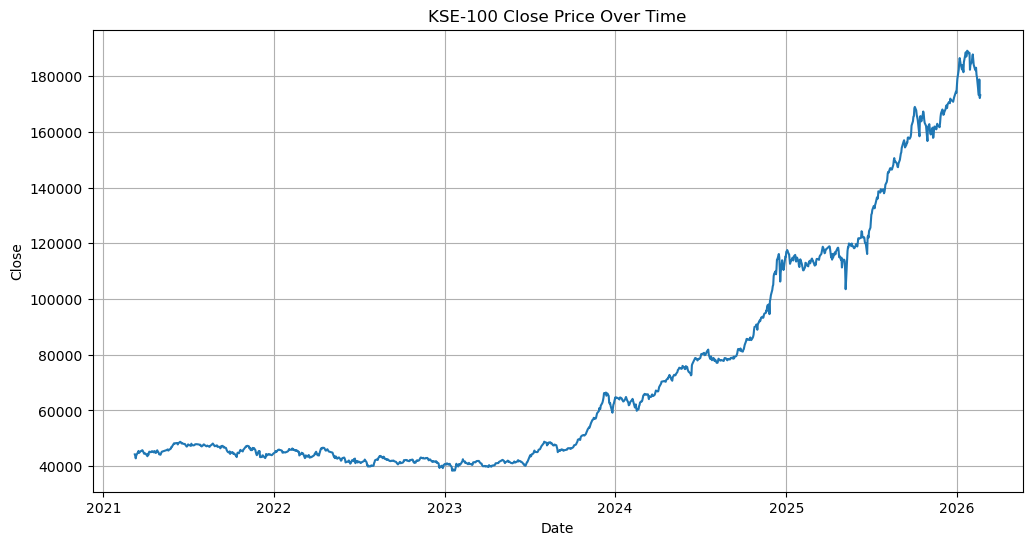

In [26]:
# Price trend 

plt.figure(figsize=(12, 6))
plt.plot(eda_df["Date"], eda_df["Close"])
plt.title("KSE-100 Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

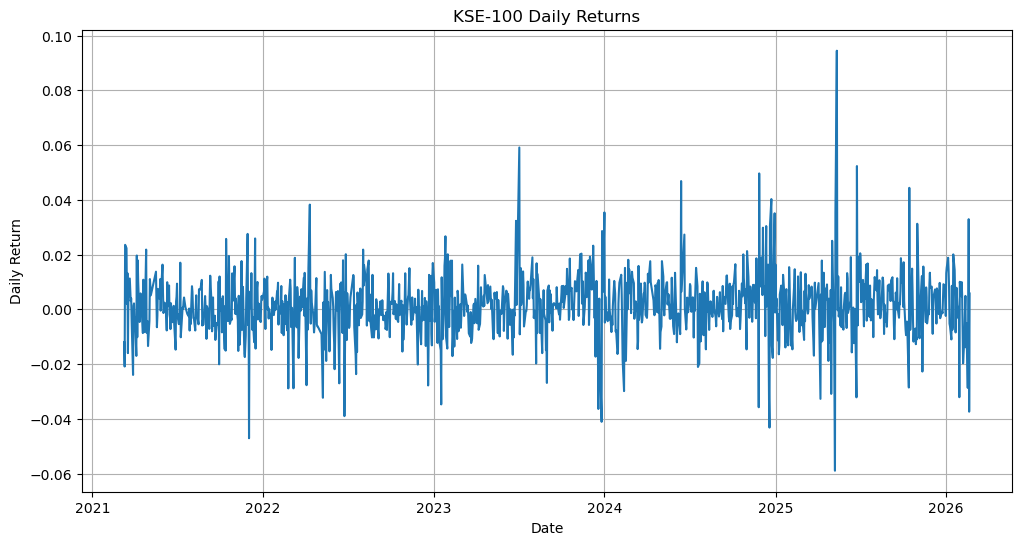

In [27]:
# Daily Returns 

plt.figure(figsize=(12, 6))
plt.plot(eda_df["Date"], eda_df["daily_return"])
plt.title("KSE-100 Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [28]:
# ADF stationarity test on close

adf_result = adfuller(eda_df["Close"].dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")

ADF Statistic: 2.6549147623117264
p-value: 0.9990833047086657
Critical Values:
  1%: -3.4357038129673962
  5%: -2.8639042041471887
  10%: -2.5680287376916997


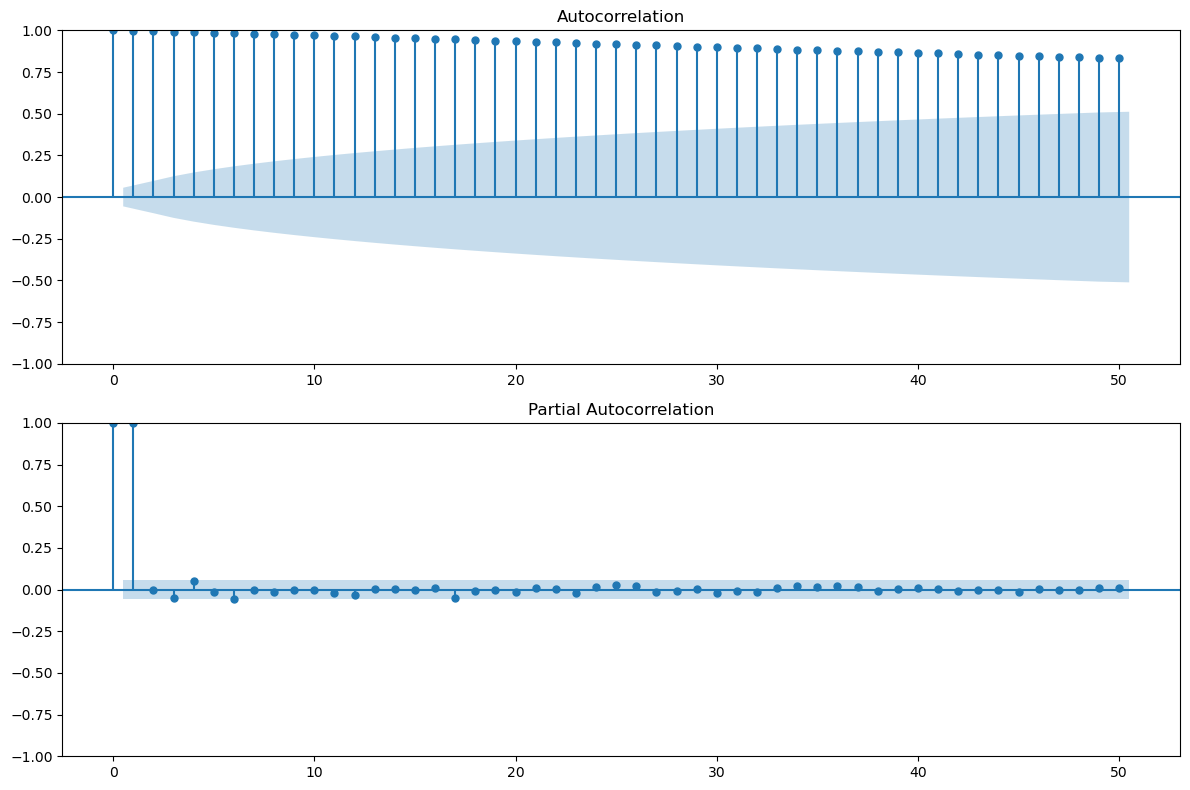

In [29]:
# ACF / PACF on close

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(eda_df["Close"].dropna(), lags=50, ax=axes[0])
plot_pacf(eda_df["Close"].dropna(), lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

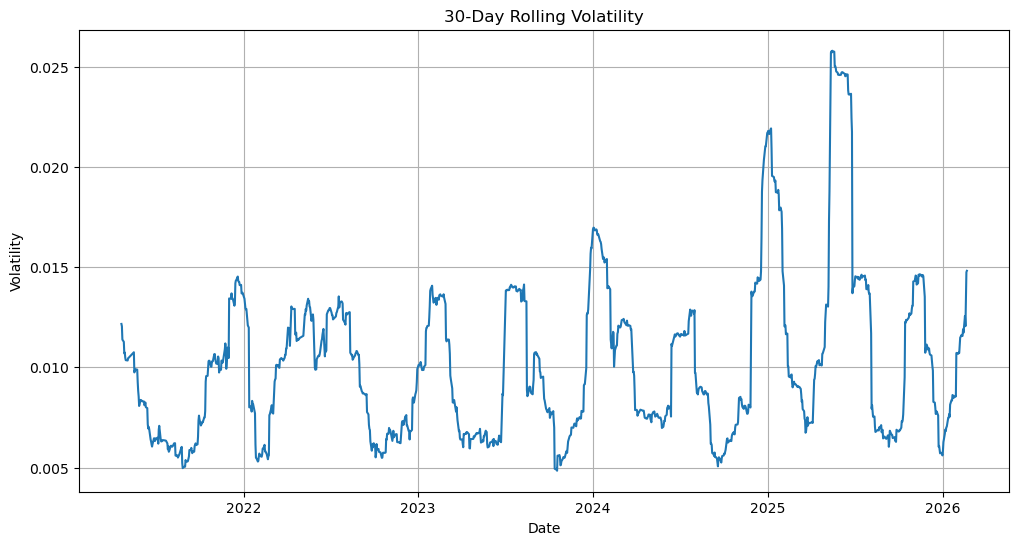

In [30]:
# 30-day rolling volatility

eda_df["Volatility_30d"] = eda_df["daily_return"].rolling(30).std()

plt.figure(figsize=(12, 6))
plt.plot(eda_df["Date"], eda_df["Volatility_30d"])
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

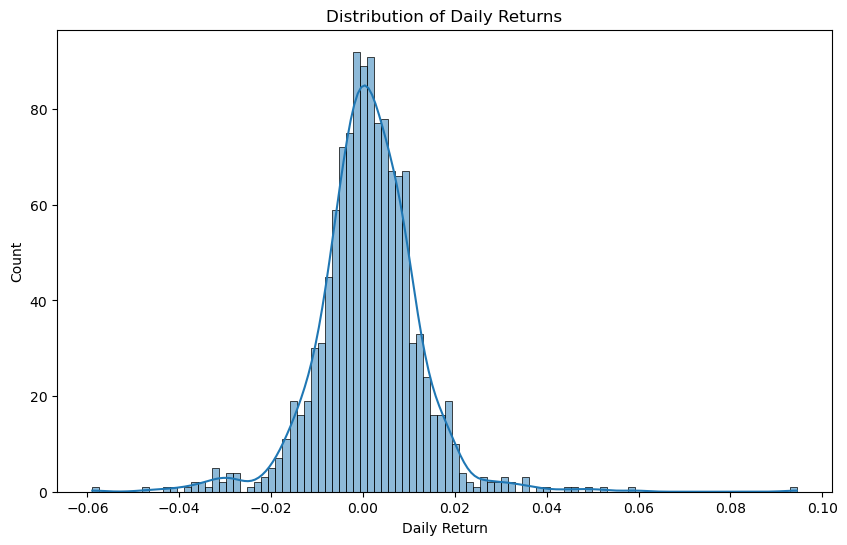

In [31]:
# Distribution of daily returns

plt.figure(figsize=(10, 6))
sns.histplot(eda_df["daily_return"].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

In [32]:
# Missing business days check

all_business_days = pd.bdate_range(start=eda_df["Date"].min(), end=eda_df["Date"].max())
missing_days = all_business_days.difference(eda_df["Date"])
print("Number of missing business days:", len(missing_days))

Number of missing business days: 67


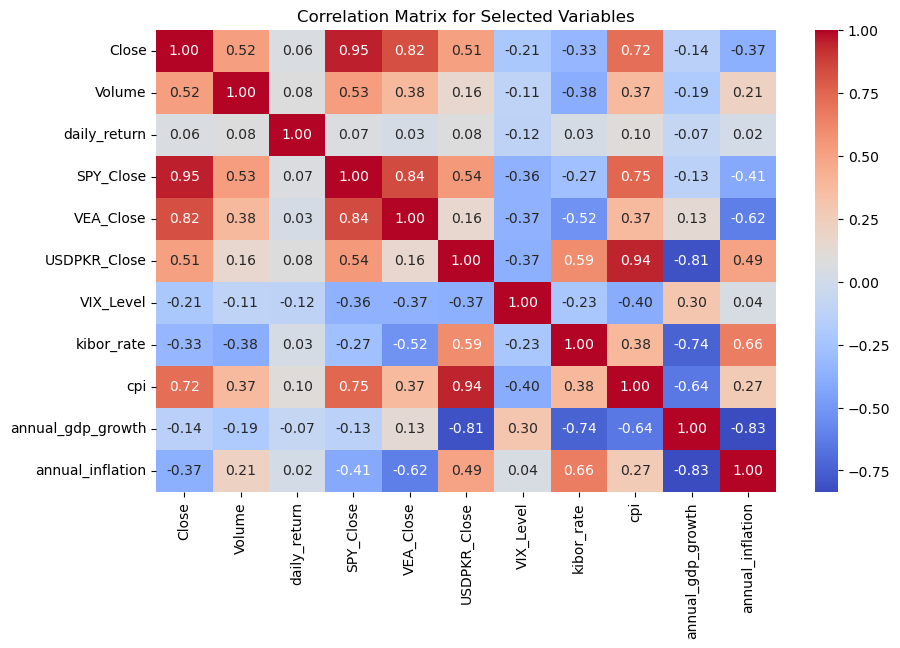

In [33]:
# Correlation snapshot with selected raw variables

corr_cols = [
    "Close", "Volume", "daily_return", "SPY_Close", "VEA_Close",
    "USDPKR_Close", "VIX_Level", "kibor_rate", "cpi",
    "annual_gdp_growth", "annual_inflation"
]
corr_cols = [c for c in corr_cols if c in eda_df.columns]

plt.figure(figsize=(10, 6))
sns.heatmap(eda_df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Selected Variables")
plt.show()

Volume skewness: 1.6636045266933002


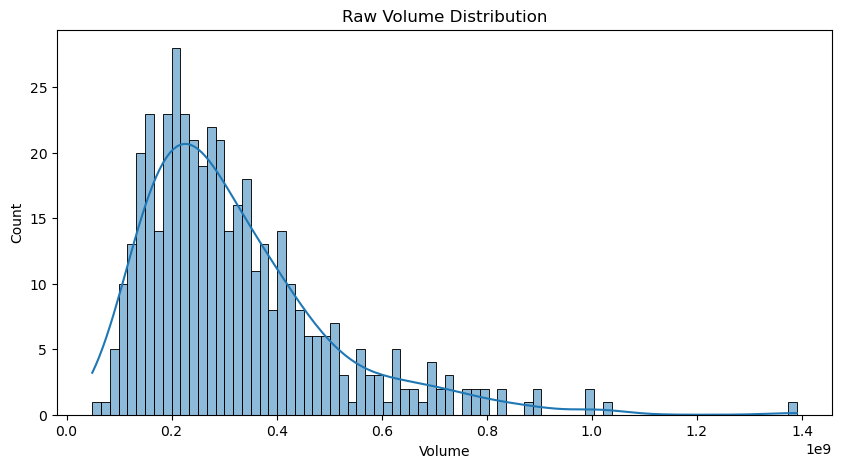

Normalized volume created using log1p because skewness > 1.


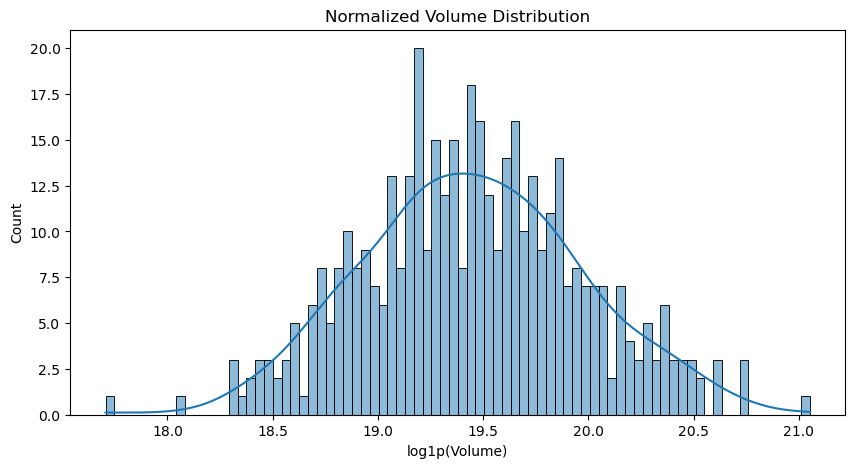

,Date,Volume,normalized_volume
0,2021-03-09,NaN,NaN
1,2021-03-10,NaN,NaN
2,2021-03-11,NaN,NaN
3,2021-03-12,NaN,NaN
4,2021-03-15,NaN,NaN


In [34]:
# Volume distribution and normalized volume decision

volume_skew = eda_df["Volume"].dropna().skew()
print("Volume skewness:", volume_skew)

plt.figure(figsize=(10, 5))
sns.histplot(eda_df["Volume"].dropna(), bins=80, kde=True)
plt.title("Raw Volume Distribution")
plt.xlabel("Volume")
plt.show()

if volume_skew > 1:
    # Log-normalized volume created because raw volume is right-skewed
    eda_df["normalized_volume"] = np.log1p(eda_df["Volume"])
    print("Normalized volume created using log1p because skewness > 1.")

    plt.figure(figsize=(10, 5))
    sns.histplot(eda_df["normalized_volume"].dropna(), bins=80, kde=True)
    plt.title("Normalized Volume Distribution")
    plt.xlabel("log1p(Volume)")
    plt.show()
else:
    # Normalized volume left equal to original volume because skewness is not severe
    eda_df["normalized_volume"] = eda_df["Volume"]
    print("Normalized volume not needed; original volume retained.")

display(eda_df[["Date", "Volume", "normalized_volume"]].head())

#### Feature engineering and final modeling dataset creation

In [35]:
feature_df = base_df.copy()

# Safety check: ensure no temporary monthly CPI merge key remains
if "cpi_month_key" in feature_df.columns:
    feature_df = feature_df.drop(columns=["cpi_month_key"])

# Normalized volume created only if raw volume is materially right-skewed
volume_skew = feature_df["Volume"].dropna().skew()
if volume_skew > 1:
    feature_df["normalized_volume"] = np.log1p(feature_df["Volume"])
else:
    feature_df["normalized_volume"] = feature_df["Volume"]

# Add technical, regime, liquidity, and drawdown features
feature_df = add_technical_features(feature_df)

# Target is next-day close price
feature_df["target_next_close"] = feature_df["Close"].shift(-1)

# Internal modeling target is next-day log return to reduce non-stationarity
feature_df["target_next_log_return"] = np.log(feature_df["target_next_close"] / feature_df["Close"])

print("Feature-engineered dataset shape:", feature_df.shape)
display(feature_df.head())

# Save the full final dataframe after cleaning, feature engineering, and data treatments
feature_df.to_csv("final_feature_engineered_dataset.csv", index=False)
print("Saved: final_feature_engineered_dataset.csv")

Feature-engineered dataset shape: (1227, 87)


,Date,Price,Open,High,Low,Vol.,Change %,Log_Return,SPY_Log_Return,EEM_Log_Return,VIX_Level,VIX_Change,Days_Since_Last_Trade,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,Close,Volume,prev_close,daily_return,year,SPY_Close,VEA_Close,USDPKR_Close,SPY_Close_Log_Return,VEA_Close_Log_Return,USDPKR_Log_Return,annual_gdp_growth,annual_inflation,cpi,kibor_rate,normalized_volume,SMA_10,SMA_20,SMA_50,SMA_200,EMA_10,EMA_20,EMA_50,Golden_Cross,EMA_crossover,RSI_14,RSI_OB,RSI_OS,MACD_Line,MACD_Signal,MACD_Hist,ROC_5,BB_Upper,BB_Lower,BB_Middle,BB_Width,BB_Pct,True_Range,ATR_14,ATR_Pct,HV_20,Volume_SMA_20,Vol_Ratio,Volume_Median_20,Volume_Regime,Trend_Regime,Liquidity_Stress,kibor_rate_ma_5,kibor_rate_ma_20,kibor_rate_change_5,kibor_rate_change_20,close_lag_1,close_lag_2,close_lag_3,close_lag_5,close_lag_10,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,rolling_max_close_63,drawdown_63,max_drawdown_63,days_since_high_63,rolling_max_close_252,drawdown_252,max_drawdown_252,days_since_high_252,target_next_close,target_next_log_return
0,2021-03-09,44222.91,45051.06,45129.55,43946.30,NaN,-1.84,-0.018553,-0.004991,-0.027306,25.469999,0.809999,1,0,0,0,44222.91,NaN,NaN,NaN,2021,387.170013,48.900002,156.750000,NaN,NaN,NaN,6.513886,9.496211,143.61,7.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1183.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.660,7.660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43691.68,-0.012085
1,2021-03-10,43691.68,44222.91,44424.04,43620.84,NaN,-1.20,-0.012085,0.014176,0.021717,24.030001,-1.439999,1,0,0,0,43691.68,NaN,44222.91,-0.012013,2021,389.579987,49.110001,156.649994,0.006205,0.004285,-0.000638,6.513886,9.496211,143.61,7.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,803.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.660,7.660,NaN,NaN,44222.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42779.76,-0.021093
2,2021-03-11,42779.76,43691.68,43891.00,42689.42,NaN,-2.09,-0.021093,0.006205,-0.004493,22.559999,-1.470001,1,0,0,0,42779.76,NaN,43691.68,-0.020872,2021,393.529999,49.470001,156.699997,0.010088,0.007304,0.000319,6.513886,9.496211,143.61,7.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1201.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.730,7.730,NaN,NaN,43691.68,44222.91,NaN,NaN,NaN,-0.012013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43788.08,0.023297
3,2021-03-12,43788.08,42779.76,43986.18,42779.76,NaN,2.36,0.023297,0.010088,0.031039,21.910000,-0.650000,1,0,0,0,43788.08,NaN,42779.76,0.023570,2021,394.059998,49.590000,156.949997,0.001346,0.002423,0.001594,6.513886,9.496211,143.61,7.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1206.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.770,7.770,NaN,NaN,42779.76,43691.68,44222.91,NaN,NaN,-0.020872,-0.012013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44766.59,0.022100
4,2021-03-15,44766.59,43788.08,44839.19,43788.08,NaN,2.23,0.022100,0.001346,-0.017989,20.690001,-1.219999,3,1,0,0,44766.59,NaN,43788.08,0.022346,2021,396.410004,49.709999,155.327301,0.005946,0.002417,-0.010393,6.513886,9.496211,143.61,7.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1051.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.792,7.792,NaN,NaN,43788.08,42779.76,43691.68,NaN,NaN,0.023570,-0.020872,-0.012013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44857.06,0.002019


Saved: final_feature_engineered_dataset.csv


#### Correlation and multicollinearity testing, then feature selection

In [36]:
model_df = feature_df.copy()

# Keep rows where the modeling target exists
model_df = model_df.dropna(subset=["target_next_close", "target_next_log_return"]).reset_index(drop=True)

# Candidate features restricted to numeric columns only
excluded_cols = {
    "Date", "year",
    "target_next_close", "target_next_log_return"
}

candidate_features = [
    col for col in model_df.columns
    if col not in excluded_cols and pd.api.types.is_numeric_dtype(model_df[col])
]

# Remove fully empty numeric columns if any
candidate_features = [col for col in candidate_features if model_df[col].notna().sum() > 0]

print("Number of candidate numeric features:", len(candidate_features))


Number of candidate numeric features: 83


In [37]:
# # Correlation with target

In [38]:
target_corr = (
    model_df[candidate_features + ["target_next_close"]]
    .corr()["target_next_close"]
    .drop("target_next_close")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Top correlations with target_next_close:")
display(target_corr.head(25).to_frame("corr_with_target"))

Top correlations with target_next_close:


,corr_with_target
Price,0.999699
Close,0.999699
High,0.999585
Low,0.999574
Open,0.999448
prev_close,0.999356
close_lag_1,0.999356
EMA_10,0.999137
close_lag_2,0.999092
SMA_10,0.998917


In [39]:
# High-correlation pair filtering

corr_matrix = model_df[candidate_features].corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_drop = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.95)
]

correlation_filtered_features = [col for col in candidate_features if col not in high_corr_drop]

print("Dropped due to pairwise correlation > 0.95:", len(high_corr_drop))
print("Remaining after correlation filter:", len(correlation_filtered_features))

Dropped due to pairwise correlation > 0.95: 32
Remaining after correlation filter: 51


In [40]:
# VIF filtering

selected_features = iterative_vif_filter(
    dataframe=model_df,
    feature_list=correlation_filtered_features,
    vif_threshold=10.0
)

print("Remaining after VIF filter:", len(selected_features))
print("Selected features:")
display(pd.DataFrame({"selected_feature": selected_features}))

# Final VIF table
final_vif = calculate_vif(model_df, selected_features)
display(final_vif.head(30))

Remaining after VIF filter: 35
Selected features:


,selected_feature
0,Change %
1,SPY_Log_Return
2,EEM_Log_Return
3,VIX_Level
4,VIX_Change
5,Is_Post_Holiday
6,Is_IMF_Event
7,IMF_3Day_Window
8,VEA_Close
9,USDPKR_Close


,feature,VIF
0,RSI_OB,9.477411
1,ROC_5,8.872564
2,BB_Pct,8.262665
3,cpi,7.564726
4,VEA_Close,7.009992
5,BB_Width,6.004780
6,days_since_high_63,5.731510
7,kibor_rate_change_20,5.183816
8,SPY_Log_Return,4.394201
9,USDPKR_Close,4.105811


### Train / validation / evaluation split and model training

In [41]:
# Chronological split:
# train = first 70%
# validation = next 20%
# evaluation = final 10%
train_df, val_df, test_df = chronological_split(model_df, 0.70, 0.20, 0.10)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Evaluation/Test shape:", test_df.shape)

X_train = train_df[selected_features]
X_val = val_df[selected_features]
X_test = test_df[selected_features]

y_train = train_df["target_next_log_return"]
y_val_actual_price = val_df["target_next_close"]
y_test_actual_price = test_df["target_next_close"]

Train shape: (858, 87)
Validation shape: (245, 87)
Evaluation/Test shape: (123, 87)


In [42]:
# HistGradientBoosting is used here for nonlinear relationships and mixed feature scales
# Median imputation handles missing values conservatively without using future data
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=5,
        max_iter=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('regressor',
                 HistGradientBoostingRegressor(learning_rate=0.03, max_depth=5,
                                               max_iter=300,
                                               random_state=42))])

In [43]:
# Convert predicted next-day log return into predicted next-day price
val_pred_log_return = model.predict(X_val)
test_pred_log_return = model.predict(X_test)

val_pred_price = val_df["Close"].values * np.exp(val_pred_log_return)
test_pred_price = test_df["Close"].values * np.exp(test_pred_log_return)

val_metrics = regression_metrics(y_val_actual_price, val_pred_price)
test_metrics = regression_metrics(y_test_actual_price, test_pred_price)

metrics_df = pd.DataFrame([val_metrics, test_metrics], index=["Validation", "Evaluation"])
display(metrics_df)


,MAE,RMSE,MAPE,R2
Validation,1088.080020,1549.599757,0.009642,0.99266
Evaluation,1457.603768,2041.779269,0.008589,0.96234


In [44]:
# Save predictions back into split dataframes
val_results = val_df[["Date", "Close", "target_next_close"]].copy()
val_results["predicted_next_close"] = val_pred_price

test_results = test_df[["Date", "Close", "target_next_close"]].copy()
test_results["predicted_next_close"] = test_pred_price

display(val_results.head())
display(test_results.head())

,Date,Close,target_next_close,predicted_next_close
858,2024-09-04,78848.01,78863.34,78531.655120
859,2024-09-05,78863.34,78897.73,78729.889939
860,2024-09-06,78897.73,78615.00,78698.506345
861,2024-09-09,78615.00,79286.74,78461.646207
862,2024-09-10,79286.74,78651.80,79277.050376


,Date,Close,target_next_close,predicted_next_close
1103,2025-08-29,148617.78,149971.13,148843.075585
1104,2025-09-01,149971.13,150975.48,149447.189920
1105,2025-09-02,150975.48,152201.88,151162.296747
1106,2025-09-03,152201.88,152665.72,152418.576094
1107,2025-09-04,152665.72,154277.19,153102.664813


### Plot model error metrics and actual vs predicted prices

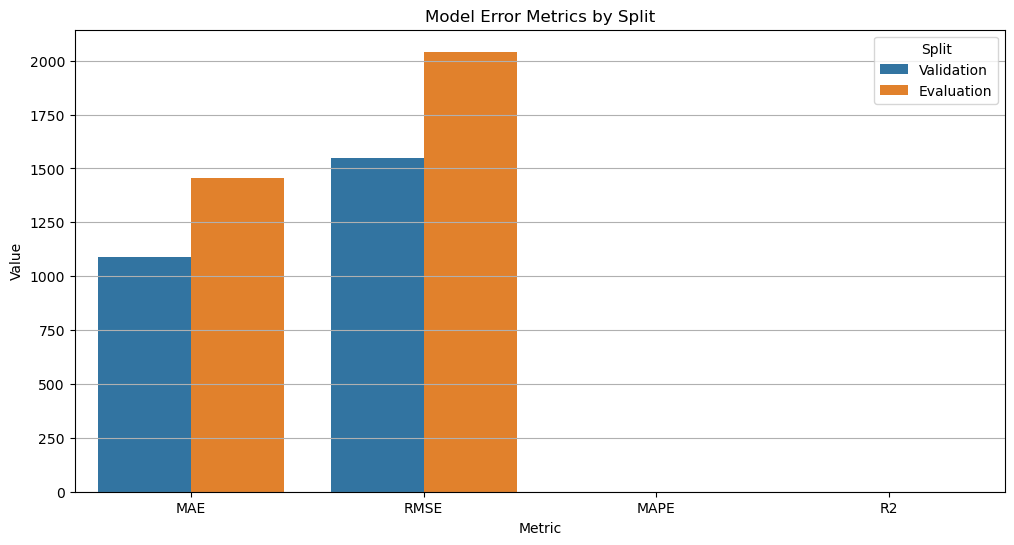

In [45]:
# Metrics bar chart

plot_metrics_df = metrics_df.reset_index().rename(columns={"index": "Split"})
plot_metrics_long = plot_metrics_df.melt(id_vars="Split", var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_metrics_long, x="Metric", y="Value", hue="Split")
plt.title("Model Error Metrics by Split")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.grid(True, axis="y")
plt.show()

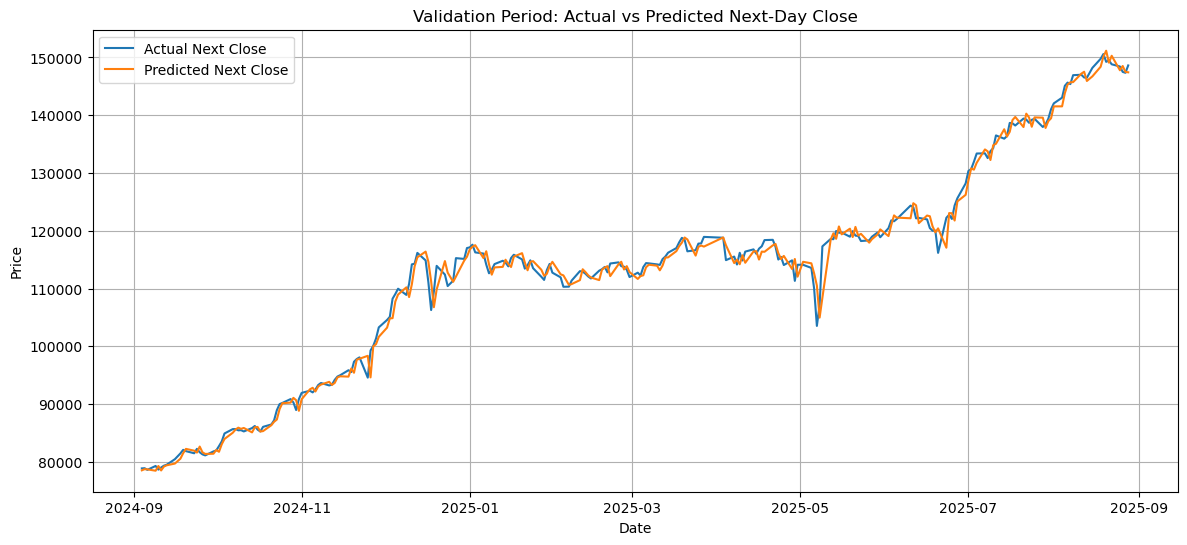

In [46]:
# Validation actual vs predicted

plt.figure(figsize=(14, 6))
plt.plot(val_results["Date"], val_results["target_next_close"], label="Actual Next Close")
plt.plot(val_results["Date"], val_results["predicted_next_close"], label="Predicted Next Close")
plt.title("Validation Period: Actual vs Predicted Next-Day Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

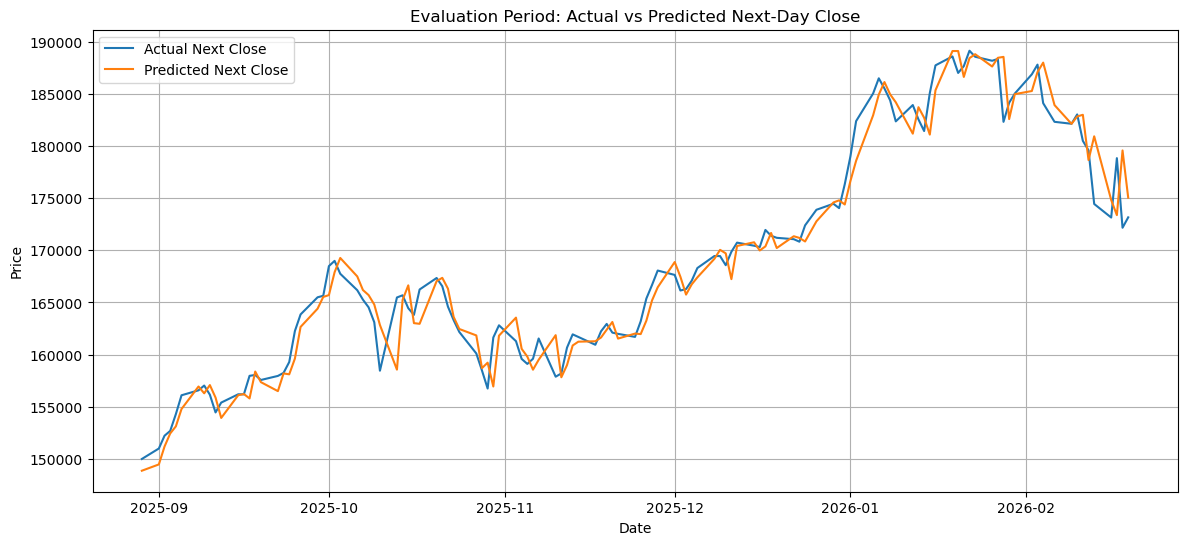

In [47]:
# Evaluation actual vs predicted

plt.figure(figsize=(14, 6))
plt.plot(test_results["Date"], test_results["target_next_close"], label="Actual Next Close")
plt.plot(test_results["Date"], test_results["predicted_next_close"], label="Predicted Next Close")
plt.title("Evaluation Period: Actual vs Predicted Next-Day Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

### Create trade signals and run backtest on the validation data

In [48]:
backtest_df = val_results.copy()

# Predicted next-day return from today's close
backtest_df["predicted_next_return"] = backtest_df["predicted_next_close"] / backtest_df["Close"] - 1

# Trade signal based on predicted next-day price relative to today's close
backtest_df["trade_signal"] = backtest_df.apply(
    lambda row: generate_trade_signal(
        predicted_next_close=row["predicted_next_close"],
        current_close=row["Close"],
        buy_threshold=BUY_THRESHOLD,
        sell_threshold=SELL_THRESHOLD
    ),
    axis=1
)

display(backtest_df.head())

print("Trade signal counts:")
display(backtest_df["trade_signal"].value_counts())

# Run portfolio backtest
backtest_results = run_backtest(backtest_df, initial_capital=INITIAL_CAPITAL)

# Final portfolio and benchmark values
final_portfolio_value = backtest_results["portfolio_value"].iloc[-1]
final_index_value = backtest_results["benchmark_index_value"].iloc[-1]

print(f"Final benchmark index value over validation period: ${final_index_value:,.2f}")
print(f"Final portfolio value over validation period: ${final_portfolio_value:,.2f}")

display(backtest_results.head())
display(backtest_results.tail())

,Date,Close,target_next_close,predicted_next_close,predicted_next_return,trade_signal
858,2024-09-04,78848.01,78863.34,78531.655120,-0.004012,HOLD
859,2024-09-05,78863.34,78897.73,78729.889939,-0.001692,HOLD
860,2024-09-06,78897.73,78615.00,78698.506345,-0.002525,HOLD
861,2024-09-09,78615.00,79286.74,78461.646207,-0.001951,HOLD
862,2024-09-10,79286.74,78651.80,79277.050376,-0.000122,HOLD


Trade signal counts:


HOLD    245
Name: trade_signal, dtype: int64

Final benchmark index value over validation period: $186,870.31
Final portfolio value over validation period: $100,000.00


,Date,Close,target_next_close,predicted_next_close,predicted_next_return,trade_signal,units_held,portfolio_value,benchmark_index_value
858,2024-09-04,78848.01,78863.34,78531.655120,-0.004012,HOLD,0.0,100000.0,100000.000000
859,2024-09-05,78863.34,78897.73,78729.889939,-0.001692,HOLD,0.0,100000.0,100019.442469
860,2024-09-06,78897.73,78615.00,78698.506345,-0.002525,HOLD,0.0,100000.0,100063.058028
861,2024-09-09,78615.00,79286.74,78461.646207,-0.001951,HOLD,0.0,100000.0,99704.482079
862,2024-09-10,79286.74,78651.80,79277.050376,-0.000122,HOLD,0.0,100000.0,100556.424950


,Date,Close,target_next_close,predicted_next_close,predicted_next_return,trade_signal,units_held,portfolio_value,benchmark_index_value
1098,2025-08-22,149493.06,148815.31,150289.299472,0.005326,HOLD,0.0,100000.0,189596.490767
1099,2025-08-25,148815.31,148435.06,147782.270362,-0.006942,HOLD,0.0,100000.0,188736.925637
1100,2025-08-26,148435.06,147494.03,148517.638902,0.000556,HOLD,0.0,100000.0,188254.668697
1101,2025-08-27,147494.03,147343.52,147495.114034,0.000007,HOLD,0.0,100000.0,187061.195330
1102,2025-08-28,147343.52,148617.78,147428.175643,0.000575,HOLD,0.0,100000.0,186870.309092


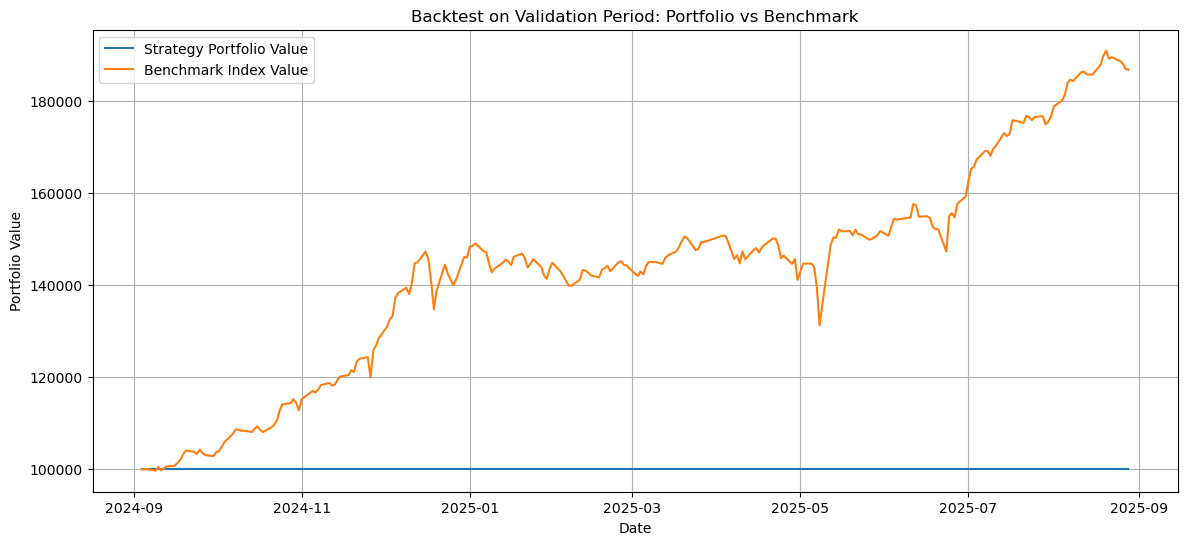

In [49]:
# Plot backtest portfolio value vs benchmark and export outputs
# Portfolio value vs benchmark

plt.figure(figsize=(14, 6))
plt.plot(backtest_results["Date"], backtest_results["portfolio_value"], label="Strategy Portfolio Value")
plt.plot(backtest_results["Date"], backtest_results["benchmark_index_value"], label="Benchmark Index Value")
plt.title("Backtest on Validation Period: Portfolio vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

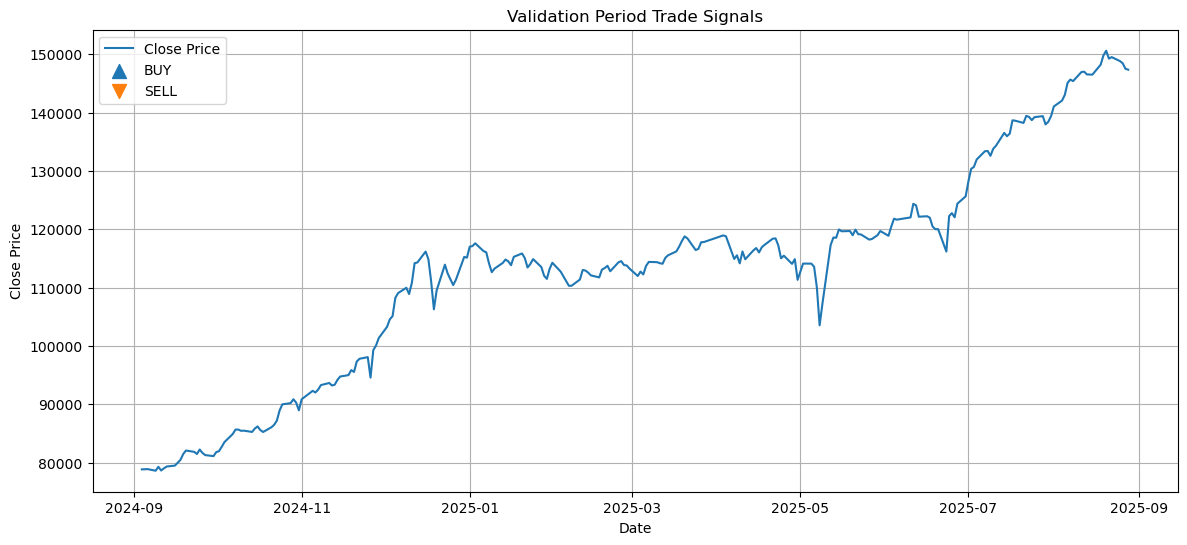

In [50]:
# Plot trade signals on price chart

plt.figure(figsize=(14, 6))
plt.plot(backtest_results["Date"], backtest_results["Close"], label="Close Price")

buy_points = backtest_results[backtest_results["trade_signal"] == "BUY"]
sell_points = backtest_results[backtest_results["trade_signal"] == "SELL"]

plt.scatter(buy_points["Date"], buy_points["Close"], marker="^", s=100, label="BUY")
plt.scatter(sell_points["Date"], sell_points["Close"], marker="v", s=100, label="SELL")

plt.title("Validation Period Trade Signals")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
# # Save outputs

# metrics_df.to_csv("model_metrics.csv")
# val_results.to_csv("validation_predictions.csv", index=False)
# test_results.to_csv("evaluation_predictions.csv", index=False)
# backtest_results.to_csv("validation_backtest_results.csv", index=False)

# print("Saved files:")
# print("- final_feature_engineered_dataset.csv")
# print("- model_metrics.csv")
# print("- validation_predictions.csv")
# print("- evaluation_predictions.csv")
# print("- validation_backtest_results.csv")

In [53]:
# Save base dataset

base_df.to_excel("base_df.xlsx", index=False)